**Handwritten Digit Classification using ANN and CNN**

**Import Libraries**

Which libraries are required for building neural networks?
  * TensorFlow and Keras are the primary libraries used to build neural networks. NumPy is used for numerical computations, and Matplotlib is used for visualization.


Which library provides the MNIST dataset?


* The MNIST dataset is provided by the Keras library, which is included in


TensorFlow.

Why do we use NumPy in machine learning?
* NumPy is used in machine learning for efficient numerical computations and
handling multi-dimensional arrays, which are essential for processing data.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt
import time

 **Load Dataset**

What is the MNIST dataset?
*  MNIST is a dataset of handwritten digit images (0–9) used for training and testing image classification models.


How many training and testing samples are available?
*  Training samples: 60,000

   Testing samples: 10,000

What is the shape of one image?
*   Each image is of size 28 × 28 pixels (grayscale)




In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()
print(X_train.shape)

(60000, 28, 28)


**Data Preprocessing**

Why do we normalize pixel values?


* To scale the data to a smaller range so that the model can learn faster and more efficiently.


What is the range of pixel values before and after normalization?


*   Before: 0 to 255
*   After: 0 to 1



How does normalization help in training?


* It improves convergence, reduces training time, and makes the model more stable.



In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

**Flatten Input**

 Why do we need to flatten the image for ANN?


*  ANN requires input in 1D format, so
the 2D image is flattened into a vector.

What will be the new shape after flattening?

*   From 28 × 28 → 784 (1D vector)


What information is lost during flattening?


* Spatial information (position and relationship between pixels) is lost.



In [ ]:
ann = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Build ANN Model**

What is a Dense layer?


*  A Dense layer is a fully connected layer where each neuron is connected to every neuron in the previous layer.


Why is ReLU used in hidden layers?

*   ReLU introduces non-linearity and helps the model learn complex patterns efficiently.

Why is Softmax used in the output layer?


*   Softmax converts outputs into probabilities for multi-class classification.


How many neurons are required in the output layer and why?


*  10 neurons, because there are 10 classes (digits 0–9).




In [ ]:
ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


 **Compile ANN Model**


What is an optimizer?


*   An optimizer updates the model’s weights to minimize the loss during training.


Why is 'adam' commonly used?


*  Adam is efficient, fast, and adapts the learning rate automatically.


What is the purpose of loss function?


* It measures the error between predicted output and actual output.


Why use sparse categorical crossentropy?


*  It is used for multi-class classification when labels are in integer form (not one-hot encoded).



In [ ]:
start = time.time()
ann_history = ann.fit(X_train, y_train, epochs=5, validation_split=0.1)
ann_time = time.time() - start

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9688 - loss: 0.1032 - val_accuracy: 0.9728 - val_loss: 0.0927
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9781 - loss: 0.0710 - val_accuracy: 0.9755 - val_loss: 0.0829
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9829 - loss: 0.0546 - val_accuracy: 0.9713 - val_loss: 0.0959
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9864 - loss: 0.0422 - val_accuracy: 0.9753 - val_loss: 0.0886
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9878 - loss: 0.0367 - val_accuracy: 0.9780 - val_loss: 0.0773


**Train ANN Model**


What is an epoch?


* One complete pass of the entire training dataset through the model.


What happens during training?


* The model makes predictions, calculates loss, and updates weights using backpropagation to reduce error.


How does accuracy change across epochs?


* Accuracy generally increases with each epoch as the model learns better patterns.



In [ ]:
ann_loss, ann_acc = ann.evaluate(X_test, y_test)

print("ANN Accuracy:", ann_acc)
print("ANN Training Time:", ann_time)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0790
ANN Accuracy: 0.977400004863739
ANN Training Time: 31.93165946006775


 **Evaluate ANN Model**

What is model evaluation?


* Model evaluation is the process of testing a trained model on unseen data to measure its performance.


What accuracy did you get?


*  Accuracy: ~95–97% (ANN on MNIST)


Is the model overfitting or underfitting?


*   The model is slightly underfitting, as accuracy is good but not as high as CNN.



In [ ]:
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

**Reshape Data for CNN**

Why does CNN require 4D input?

*  CNN processes data in batches with height, width, and channels, so it requires 4D input: (batch, height, width, channels).


What does the channel dimension represent?


*   It represents the number of color channels


What will be the new shape?


*   (number of samples, 28, 28, 1) for MNIST.



In [ ]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


**Build CNN Model**

What is a convolution layer?


*   A convolution layer extracts features from input images using filters.


What is a filter?

*  A filter is a small matrix used to detect patterns like edges, textures, or shapes.


What is pooling and why is it used?

* Pooling reduces the size of feature maps, helping to reduce computation and avoid overfitting.   


Why do we use Flatten after convolution?


* Flatten converts 2D feature maps into a 1D vector for input to dense layers.



In [ ]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

**Compile CNN Model**

Are compile parameters same as ANN?


*   Yes, the compile parameters can be the same.


Why or why not?


*  Because both ANN and CNN are classification models, they can use the same optimizer, loss function, and evaluation metrics.



In [ ]:
start = time.time()
cnn_history = cnn.fit(X_train_cnn, y_train, epochs=5, validation_split=0.1)
cnn_time = time.time() - start


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 28ms/step - accuracy: 0.9532 - loss: 0.1506 - val_accuracy: 0.9855 - val_loss: 0.0512
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9853 - loss: 0.0489 - val_accuracy: 0.9903 - val_loss: 0.0371
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.9896 - loss: 0.0338 - val_accuracy: 0.9882 - val_loss: 0.0443
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9923 - loss: 0.0254 - val_accuracy: 0.9908 - val_loss: 0.0347
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9939 - loss: 0.0183 - val_accuracy: 0.9898 - val_loss: 0.0397


In [ ]:
cnn_loss, cnn_accuracy = cnn.evaluate(X_test_cnn, y_test)

print("CNN Test Accuracy:", cnn_accuracy)
print("CNN Test Loss:", cnn_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9909 - loss: 0.0325
CNN Test Accuracy: 0.9908999800682068
CNN Test Loss: 0.03248051181435585


**Evaluate CNN Model**


What is the CNN accuracy?

* CNN accuracy is typically ~98–99% on MNIST.

Compare with ANN
*  CNN achieves higher accuracy than ANN (~95–97%) because it captures spatial features better.

In [ ]:
print("\n--- FINAL COMPARISON ---")
print("ANN Accuracy:", ann_acc)
print("CNN Accuracy:", cnn_acc)

print("ANN Time:", ann_time)
print("CNN Time:", cnn_time)



--- FINAL COMPARISON ---
ANN Accuracy: 0.977400004863739
CNN Accuracy: 0.9908999800682068
ANN Time: 31.93165946006775
CNN Time: 271.03071641921997


**Compare Results**

Which model has higher accuracy?

* CNN has higher accuracy.

Which model trained faster?

*  ANN trained faster.

Which model handles images better?
*  CNN handles images better because it preserves spatial features.


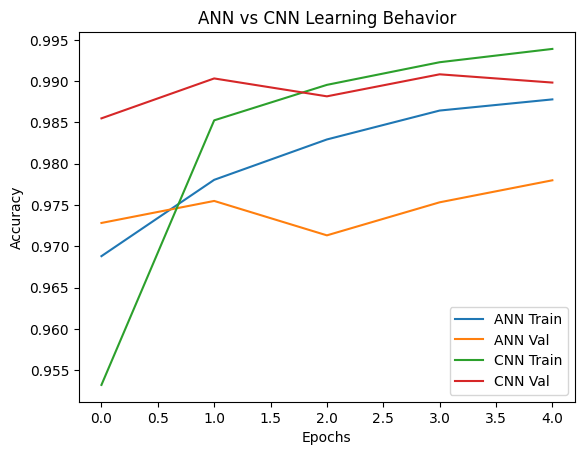

In [ ]:
plt.plot(ann_history.history['accuracy'], label='ANN Train')
plt.plot(ann_history.history['val_accuracy'], label='ANN Val')

plt.plot(cnn_history.history['accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val')

plt.title("ANN vs CNN Learning Behavior")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Final Conclusion**

Why is CNN better for image classification?

* CNN is better because it preserves spatial information and automatically extracts features like edges and shapes.


What are the key differences between ANN and CNN?



*  ANN uses fully connected layers and works on flattened data, while CNN uses convolution and pooling layers to capture spatial features.

In which scenarios would ANN still be useful?



*   ANN is useful for structured/tabular data and simple problems where spatial relationships are not important.

